# Exploration et segmentation : Bank Marketing

Objectif : mesurer la conversion par segment, repérer les biais du jeu de données (dérive temporelle) et comparer les lifts bruts et ajustés à la période
Données : UCI Bank Marketing (bank-full.csv), lues depuis PostgreSQL (`bank_segments`)

In [1]:
# connexion

import os
from getpass import getpass

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from statsmodels.stats.proportion import proportion_confint

password = os.environ.get("BANK_DB_PASSWORD") or getpass("Mot de passe analyst : ")
engine = create_engine(URL.create(
    "postgresql+psycopg2", username="analyst", password=password,
    host="localhost", port=5432, database="bank"))

os.makedirs("../docs/figures", exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# conversion par segment, avec intervalle de confiance de Wilson

seg = pd.read_sql("""
    SELECT segment, COUNT(*) AS n, SUM(converted) AS k
    FROM bank_segments GROUP BY segment ORDER BY segment""", engine)
seg["taux"] = seg["k"] / seg["n"]
seg["bas"], seg["haut"] = proportion_confint(seg["k"], seg["n"], method="wilson")
seg

,segment,n,k,taux,bas,haut
0,1 Ancien souscripteur,1511,978,0.647253,0.622815,0.670945
1,2 Recontacté récent (sans succès),2919,514,0.176088,0.162698,0.190329
2,3 Recontacté ancien (sans succès),3827,413,0.107917,0.098477,0.118144
3,4 Nouveau - solde élevé,8869,1106,0.124704,0.117990,0.131743
4,5 Nouveau - solde moyen,18287,1688,0.092306,0.088196,0.096587
5,6 Nouveau - solde faible,9798,590,0.060216,0.055676,0.065101


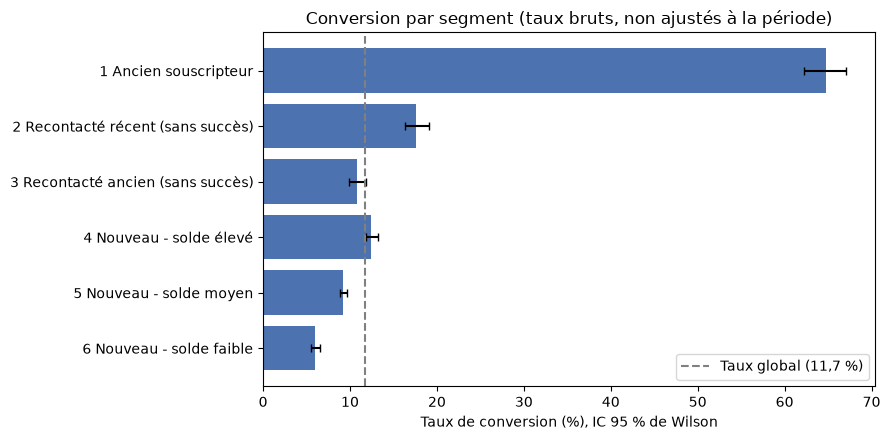

In [3]:
# graphique avec barres d'erreur

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(seg["segment"], 100 * seg["taux"],
        xerr=[100 * (seg["taux"] - seg["bas"]), 100 * (seg["haut"] - seg["taux"])],
        color="#4C72B0", capsize=3)
ax.axvline(100 * seg["k"].sum() / seg["n"].sum(), color="grey", ls="--",
           label="Taux global (11,7 %)")
ax.invert_yaxis()
ax.set_xlabel("Taux de conversion (%), IC 95 % de Wilson")
ax.set_title("Conversion par segment (taux bruts, non ajustés à la période)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/conversion_par_segment.png", dpi=150)
plt.show()

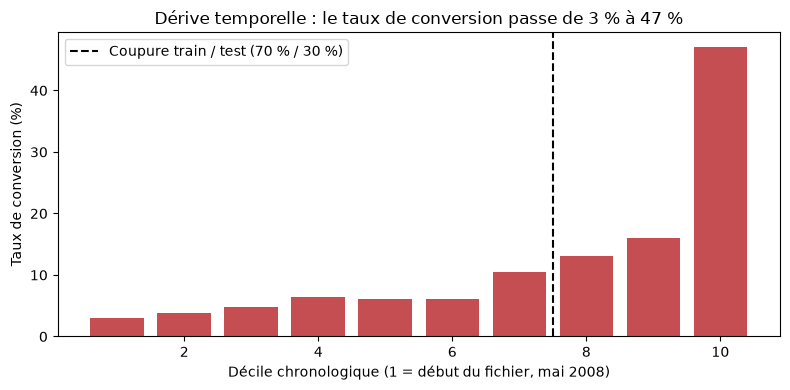

In [4]:
# la dérive temporelle

drift = pd.read_sql("""
    SELECT decile, ROUND(100.0 * AVG(converted), 2) AS taux_pct
    FROM (SELECT converted, NTILE(10) OVER (ORDER BY row_id) AS decile
          FROM bank_clean) t
    GROUP BY decile ORDER BY decile""", engine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(drift["decile"], drift["taux_pct"], color="#C44E52")
ax.axvline(7.5, color="black", ls="--", label="Coupure train / test (70 % / 30 %)")
ax.set_xlabel("Décile chronologique (1 = début du fichier, mai 2008)")
ax.set_ylabel("Taux de conversion (%)")
ax.set_title("Dérive temporelle : le taux de conversion passe de 3 % à 47 %")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/derive_temporelle.png", dpi=150)
plt.show()

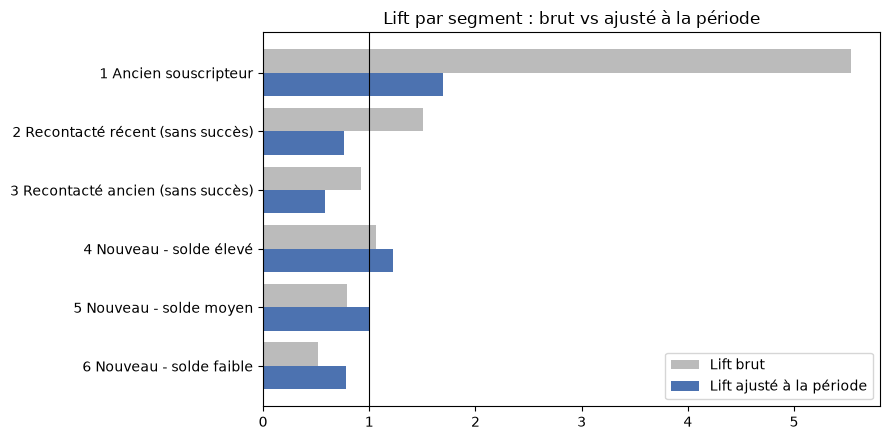

In [5]:
# lift ajusté à la période, comparé au lift brut

adj = pd.read_sql("""
    WITH d AS (
        SELECT segment, converted, NTILE(10) OVER (ORDER BY row_id) AS decile
        FROM bank_segments),
    r AS (SELECT decile, AVG(converted) AS taux_decile FROM d GROUP BY decile)
    SELECT d.segment, SUM(d.converted) / SUM(r.taux_decile) AS lift_ajuste
    FROM d JOIN r USING (decile) GROUP BY d.segment ORDER BY d.segment""", engine)

g = seg["k"].sum() / seg["n"].sum()
adj["lift_brut"] = (seg["taux"] / g).values

fig, ax = plt.subplots(figsize=(9, 4.5))
y = range(len(adj))
ax.barh([i - 0.2 for i in y], adj["lift_brut"], height=0.4, label="Lift brut", color="#BBBBBB")
ax.barh([i + 0.2 for i in y], adj["lift_ajuste"], height=0.4, label="Lift ajusté à la période", color="#4C72B0")
ax.axvline(1, color="black", lw=0.8)
ax.set_yticks(list(y)); ax.set_yticklabels(adj["segment"]); ax.invert_yaxis()
ax.set_title("Lift par segment : brut vs ajusté à la période")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/lift_brut_vs_ajuste.png", dpi=150)
plt.show()

1. La dérive temporelle (3 % → 47 %) est le principal facteur de confusion du jeu de données
2. Le gradient du solde chez les nouveaux clients (lift ajusté 1,22 / 1,01 / 0,78) est stable dans le temps
3. Les anciens souscripteurs sont le meilleur segment (lift ajusté 1,69, jusqu'à 2,65 sur la seule période de test), mais les recontactés sans succès ne surperforment pas